In [ ]:
import numpy as np
import functools as ft
import ipynb
import os
import csv
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as tck

from ipynb.fs.full.AKLT_defs import  spin_string, AKLT_sim_projective_Sz, AKLT_sim_projective_Sz2, spin_string_correlation, AKLT_sim_projective_string, Sz2Sz2_correlation, SzSz_correlation, Quantum_Fisher, AKLT_MPS, Hamiltonian, Sn   #import definitions from AKLT_defs


Generate data and export to data folder

In [10]:
num_sites, time , delta, end_string,  measure  = 6, 10, .1, 2,  'SS'
if measure == 'SS':
    measure = measure + "0-"+ str(end_string)
time_range = [i * delta for i in range(int(time/delta)+1)]



if measure == 'WM': 
    dta  = AKLT_sim_weakmeasure(num_sites, time, delta)
else: 
    func_sim, func_corr = AKLT_sim_projective_string, spin_string_correlation
    counts =  func_sim(num_sites, end_string, time, delta)
    dta = func_corr(counts )

csv_path = os.getcwd() + "/data/" + "L"+str(num_sites) + 'time'+ str(time) + 'd' + str( delta) +str(measure) +'.csv'

rows = [time_range, dta]
with open(csv_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerows(rows)

Plot data from data folder

0.9047619047619049


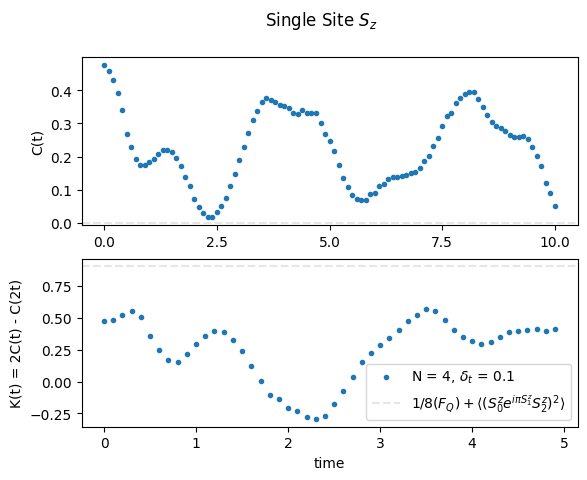

In [15]:

plt_dta = [[4, 10, .1, 1,  'SS']]

fig, ax = plt.subplots(2)

for i in plt_dta:
    num_sites, time, delta, end_string, measure = i 
    if measure == 'SS':
        measure = measure + "0-"+ str(end_string)
    csv_path = os.getcwd() + "/data/" + "L"+str(num_sites) + 'time'+ str(time) + 'd' + str( delta) +str(measure) +'.csv'


    with open(csv_path, newline='') as f:
        reader = csv.reader(f)
        [time_range, dta] = [[float(x) for x in row] for row in reader]
    
    half_len = len(dta)//2
    dta_K = [2 * dta[j] - dta[2 * j] for j in range(half_len) ]

    ax[1].scatter(time_range[:half_len]  , dta_K ,  marker= ".", label = "N = " + str(num_sites) + ", $\\delta_t$ = " + str(delta) , zorder = 3)
    ax[0].scatter(time_range  , dta ,  marker= ".", label = "N = " + str(num_sites) + ", $\\delta_t$ = " + str(delta) , zorder = 3)
    

num_qubits = num_sites *2 
psi = AKLT_MPS(num_sites, 'gs')
Ham = Hamiltonian(num_qubits)
Op = spin_string(num_sites, end_string)
QFI = Quantum_Fisher( psi, Ham, Op )

QFI_bound = 1/8 * (QFI ) + 2/3


#classical bound
ax[0].axhline( y=0, color="0.9", linestyle = "--")
#ax[1].axhline( y=1, color="0.9", linestyle = "--")
ax[1].axhline( y=QFI_bound, color="0.9", linestyle = "--", label = "$1/8(F_Q) + \\langle (S^z_0 e^{i \\pi S^z_1}S^z_2)^2\\rangle$")

#quantum bound
#ax.fill_between(time_range, 1,1.5, color = "0.6", alpha = 0.7)


fig.suptitle("Single Site $S_z$")
ax[0].xaxis.set_major_locator(tck.MultipleLocator(base = 2.5))
ax[1].xaxis.set_major_locator(tck.MultipleLocator(base = 1))
plt.xlabel("time")
ax[0].set(ylabel = "C(t)")
ax[1].set(ylabel = "K(t) = 2C(t) - C(2t)")
plt.title("")
plt.legend()

plt.show
print(QFI_bound)

In [8]:
#Save plot
fig.savefig("C:\\Users\\ianro\\Documents\\Research\\Quantum_Metrology_AKLT\\Plots\\SpinStringSquared.png")


In [27]:
plt_dta = [ [4,80,.1, 'WM']]


for i in plt_dta:
    num_sites, time, delta, measure = i 

    csv_path = os.getcwd() + "/data/" + "L"+str(num_sites) + 'time'+ str(time) + 'd' + str( delta) +str(measure) + '.csv'


    with open(csv_path, newline='') as f:
        reader = csv.reader(f)
        [time_range, dta] = [[float(x) for x in row] for row in reader]

    half_len = len(dta)//2
    dta_K = [2 * dta[j] - dta[2 * j] for j in range(half_len) ]


max(dta_K)
   

0.9912866706458524